Task 1: Use the Graph data structure (NetworkX) to build a realistic simulated transportation network with a minimum of 5 routes and 5 stations per route, ensuring comprehensive connectivity between stations through transfer points. The program must allow users to select the display unit as kilometers or miles from the start, then automatically update the distance labels on the edges based on real-world data from Google/Apple Maps. The final result must ensure geographical accuracy, strictly adhere to the design style template regarding color, circled points, and complete legend (Key) for the entire diagram.

In [34]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [35]:
choice = input("Please enter your choice (1 - Km or 2 - mi): ")
unit_label = "km" if choice == '1' else "mi"
conv_km = 0.0258
conv_mi = conv_km * 0.621371

In [36]:
pos = {
    "Pasir Ris": (1115, -456), "Tampines": (1117, -502), "Simei": (1115, -527),
    "Tanah Merah": (1094, -550), "Bedok": (1026, -550), "Kembangan": (966, -583),
    "Eunos": (929, -621), "Paya Lebar": (890, -661), "Aljunied": (854, -696),
    "Kallang": (828, -723), "Lavender": (798, -752), "Bugis": (768, -784),
    "City Hall": (701, -850), "Rafles Place": (699, -889), "Tanjong Pagar": (585, -907),
    "Outram Park": (536, -857), "Tiong Bahru": (496, -821), "Redhill": (467, -792),
    "Queenstown": (437, -765), "Commonwealth": (413, -741), "Buona Vista": (375, -714),
    "Dover": (330, -715), "Clementi": (290, -715), "Jurong East": (229, -716),
    "Chinese Garden": (180, -715), "Lakeside": (135, -715), "Boon Lay": (94, -671),
    "Pioneer": (94, -636), "Joo Koon": (94, -600), "Gul Circle": (94, -564),
    "Tuas Crescent": (94, -529), "Tuas West Road": (94, -493), "Tuas Link": (94, -457),
    "Bukit Batok": (229, -636), "Bukit Gombak": (229, -576), "Choa Chu Kang": (229, -507),
    "Yew Tee": (230, -436), "Kranji": (230, -368), "Marsiling": (267, -291),
    "Woodlands": (356, -274), "Admiralty": (417, -275), "Sembawang": (469, -275),
    "Canberra": (524, -275), "Yishun": (581, -292), "Khatib": (609, -327),
    "Yio Chu Kang": (617, -368), "Ang Mo Kio": (617, -409), "Bishan": (616, -457),
    "Braddell": (617, -484), "Toa Payoh": (617, -524), "Novena": (593, -570),
    "Newton": (576, -596), "Orchard": (504, -664), "Somerset": (555, -706),
    "Dhoby Ghaut": (622, -774), "Marina Bay": (711, -948), "Marina South Pier": (747, -983),
    "HarbourFront": (523, -953), "Chinatown": (584, -816), "Clarke Quay": (604, -793),
    "Little India": (659, -676), "Farrer Park": (658, -635), "Boon Keng": (658, -598),
    "Potong Passir": (681, -559), "Woodleigh": (716, -524), "Serangoon": (756, -485),
    "Kovan": (786, -454), "Hougang": (813, -428), "BuangKok": (838, -402),
    "SengKang": (864, -375), "Punggol": (922, -318), "Punggol Coast": (948, -293),
    "Bencoolen": (718, -761), "Bras Basah": (707, -793), "Esplanade": (764, -850),
    "Promenade": (838, -873), "Nicoll Highway": (870, -829), "Stadium": (885, -791),
    "Mountbatten": (894, -749), "Dakota": (896, -710), "MacPherson": (872, -605),
    "Tai Seng": (844, -558), "Bartley": (809, -522), "Lorong Chuan": (694, -462),
    "Marymount": (550, -469), "Caldecott": (504, -493), "Botanic Gardens": (424, -563),
    "Farrer Road": (397, -615), "Holland Village": (381, -658), "one-north": (377, -751),
    "Kent Ridge": (387, -791), "Haw Par Villa": (399, -827), "Passir Panjang": (418, -859),
    "Labrador Park": (443, -891), "Telok Blangah": (476, -921), "Bayfront": (787, -921),
    "Bukit Panjang": (320, -399), "Cashew": (320, -431), "Hilview": (320, -451),
    "Hume": (320, -471), "Beauty World": (319, -492), "King Albert Park": (320, -512),
    "Sixth Avenue": (320, -533), "Tan Kah Kee": (361, -563), "Stevens": (504, -563),
    "Rochor": (697, -712), "Downtown": (736, -933), "Telok Ayer": (663, -890),
    "Fort Canning": (581, -774), "Jalan Besar": (748, -729), "Bendemeer": (790, -689),
    "Geylang Bahru": (816, -660), "Mattar": (845, -633), "Ubi": (905, -572),
    "Kaki Bukit": (936, -540), "Bedok North": (965, -512), "Bedok Reservoir": (1017, -503),
    "Tampines West": (1071, -502), "Tampines East": (1172, -527), "Upper Changi": (1172, -555),
    "Expo": (1172, -595), "Xilin": (1167, -631), "Sungei Bedok": (1141, -654),
        "Woodlands North": (318, -236), "Woodlands South": (383, -302), "Springleaf": (407, -327),
    "Lentor": (432, -352), "Mayflower": (458, -378), "Bright Hill": (482, -403),
    "Upper Thomson": (504, -450), "Napier": (504, -600), "Orchard Boulevard": (504, -631),
    "Great World": (504, -702), "Havelock": (504, -740), "Maxwell": (596, -873),
    "Shenton Way": (659, -934), "Gardens by the Bay": (881, -918), "Tanjong Rhu": (944, -854),
    "Katong Park": (968, -830), "Tanjong Katong": (993, -804), "Marine Parade": (1018, -779),
    "Marine Terrace": (1043, -755), "Siglap": (1067, -730), "Bayshore": (1090, -708),
    "Bedok South": (1112, -685),"Changi Airport": (1219, -595)
}

In [37]:
mrt_data = {
    "East-West Line 1": {
        "stations": [
            "Pasir Ris", "Tampines", "Simei", "Tanah Merah", "Bedok", "Kembangan", "Eunos", 
            "Paya Lebar", "Aljunied", "Kallang", "Lavender", "Bugis", "City Hall", 
            "Rafles Place", "Tanjong Pagar", "Outram Park", "Tiong Bahru", "Redhill", 
            "Queenstown", "Commonwealth", "Buona Vista", "Dover", "Clementi", "Jurong East", 
            "Chinese Garden", "Lakeside", "Boon Lay", "Pioneer", "Joo Koon", "Gul Circle", 
            "Tuas Crescent", "Tuas West Road", "Tuas Link"
        ],
        "color": "#009539"
    },
    "East-West Line 2": {
        "stations": [
            "Tanah Merah","Expo","Changi Airport"
        ],
        "color": "#009539"
    },
    "North-South Line": {
        "stations": [
            "Jurong East", "Bukit Batok", "Bukit Gombak", "Choa Chu Kang", "Yew Tee", 
            "Kranji", "Marsiling", "Woodlands", "Admiralty", "Sembawang", "Canberra", 
            "Yishun", "Khatib", "Yio Chu Kang", "Ang Mo Kio", "Bishan", "Braddell", 
            "Toa Payoh", "Novena", "Newton", "Orchard", "Somerset", "Dhoby Ghaut", 
            "City Hall", "Rafles Place", "Marina Bay", "Marina South Pier"
        ],
        "color": "#D42E12"
    },
    "North-East Line": {
        "stations": [
            "HarbourFront", "Outram Park", "Chinatown", "Clarke Quay", "Dhoby Ghaut", 
            "Little India", "Farrer Park", "Boon Keng", "Potong Passir", "Woodleigh", 
            "Serangoon", "Kovan", "Hougang", "BuangKok", "SengKang", "Punggol", "Punggol Coast"
        ],
        "color": "#9900AA"
    },
    "Circle Line Main": {
        "stations": [
            "Dhoby Ghaut", "Bras Basah", "Esplanade", "Promenade", "Nicoll Highway", 
            "Stadium", "Mountbatten", "Dakota", "Paya Lebar", "MacPherson", "Tai Seng", 
            "Bartley", "Serangoon", "Lorong Chuan", "Bishan", "Marymount", "Caldecott", 
            "Botanic Gardens", "Farrer Road", "Holland Village", "Buona Vista", 
            "one-north", "Kent Ridge", "Haw Par Villa", "Passir Panjang", 
            "Labrador Park", "Telok Blangah", "HarbourFront"
        ],
        "color": "#FA9E0D"
    },
    "Circle Line Extension": {
        "stations": ["Promenade", "Bayfront", "Marina Bay"],
        "color": "#FA9E0D"
    },
    "Downtown Line": {
        "stations": [
            "Bukit Panjang", "Cashew", "Hilview", "Hume", "Beauty World", "King Albert Park", 
            "Sixth Avenue", "Tan Kah Kee", "Botanic Gardens", "Stevens", "Newton", 
            "Little India", "Rochor", "Bugis", "Promenade", "Bayfront", "Downtown", 
            "Telok Ayer", "Chinatown", "Fort Canning", "Bencoolen", "Jalan Besar", 
            "Bendemeer", "Geylang Bahru", "Mattar", "MacPherson", "Ubi", "Kaki Bukit", 
            "Bedok North", "Bedok Reservoir", "Tampines West", "Tampines", "Tampines East", 
            "Upper Changi", "Expo", "Xilin", "Sungei Bedok"
        ],
        "color": "#005EC4" 
    },
    "Thomson-East Coast Line": {
        "stations": [
            "Woodlands North", "Woodlands", "Woodlands South", "Springleaf", "Lentor", 
            "Mayflower", "Bright Hill", "Upper Thomson", "Caldecott", "Stevens", "Napier", 
            "Orchard Boulevard", "Orchard", "Great World", "Havelock", "Outram Park", 
            "Maxwell", "Shenton Way", "Marina Bay", "Gardens by the Bay", "Tanjong Rhu", 
            "Katong Park", "Tanjong Katong", "Marine Parade", "Marine Terrace", 
            "Siglap", "Bayshore", "Bedok South", "Sungei Bedok"
        ],
        "color": "#734538"
}
    
}

In [38]:
def calculate_distance(point1, point2):
    dx = point1[0] - point2[0]
    dy = point1[1] - point2[1]
    return int(np.sqrt(dx**2 + dy**2))

In [39]:
G = nx.Graph()
edge_labels = {}

In [40]:
for line_name, info in mrt_data.items():
    active_stations = [s for s in info["stations"] if s in pos]
    line_color = info["color"]
    
    for i in range(len(active_stations) - 1):
        u = active_stations[i]
        v = active_stations[i+1]
        pixel_dist = calculate_distance(pos[u], pos[v])
        
        dist_km = round(pixel_dist * conv_km, 2)        
        dist_mi = round(pixel_dist * conv_mi, 2)  
        G.add_edge(u, v, color=line_color, km=dist_km, miles=dist_mi)
        
        if (u, v) not in edge_labels and (v, u) not in edge_labels:
            if choice == '1':
                val = dist_km 
            else:
                val = dist_mi
            
            edge_labels[(u, v)] = f"{val}{unit_label}"

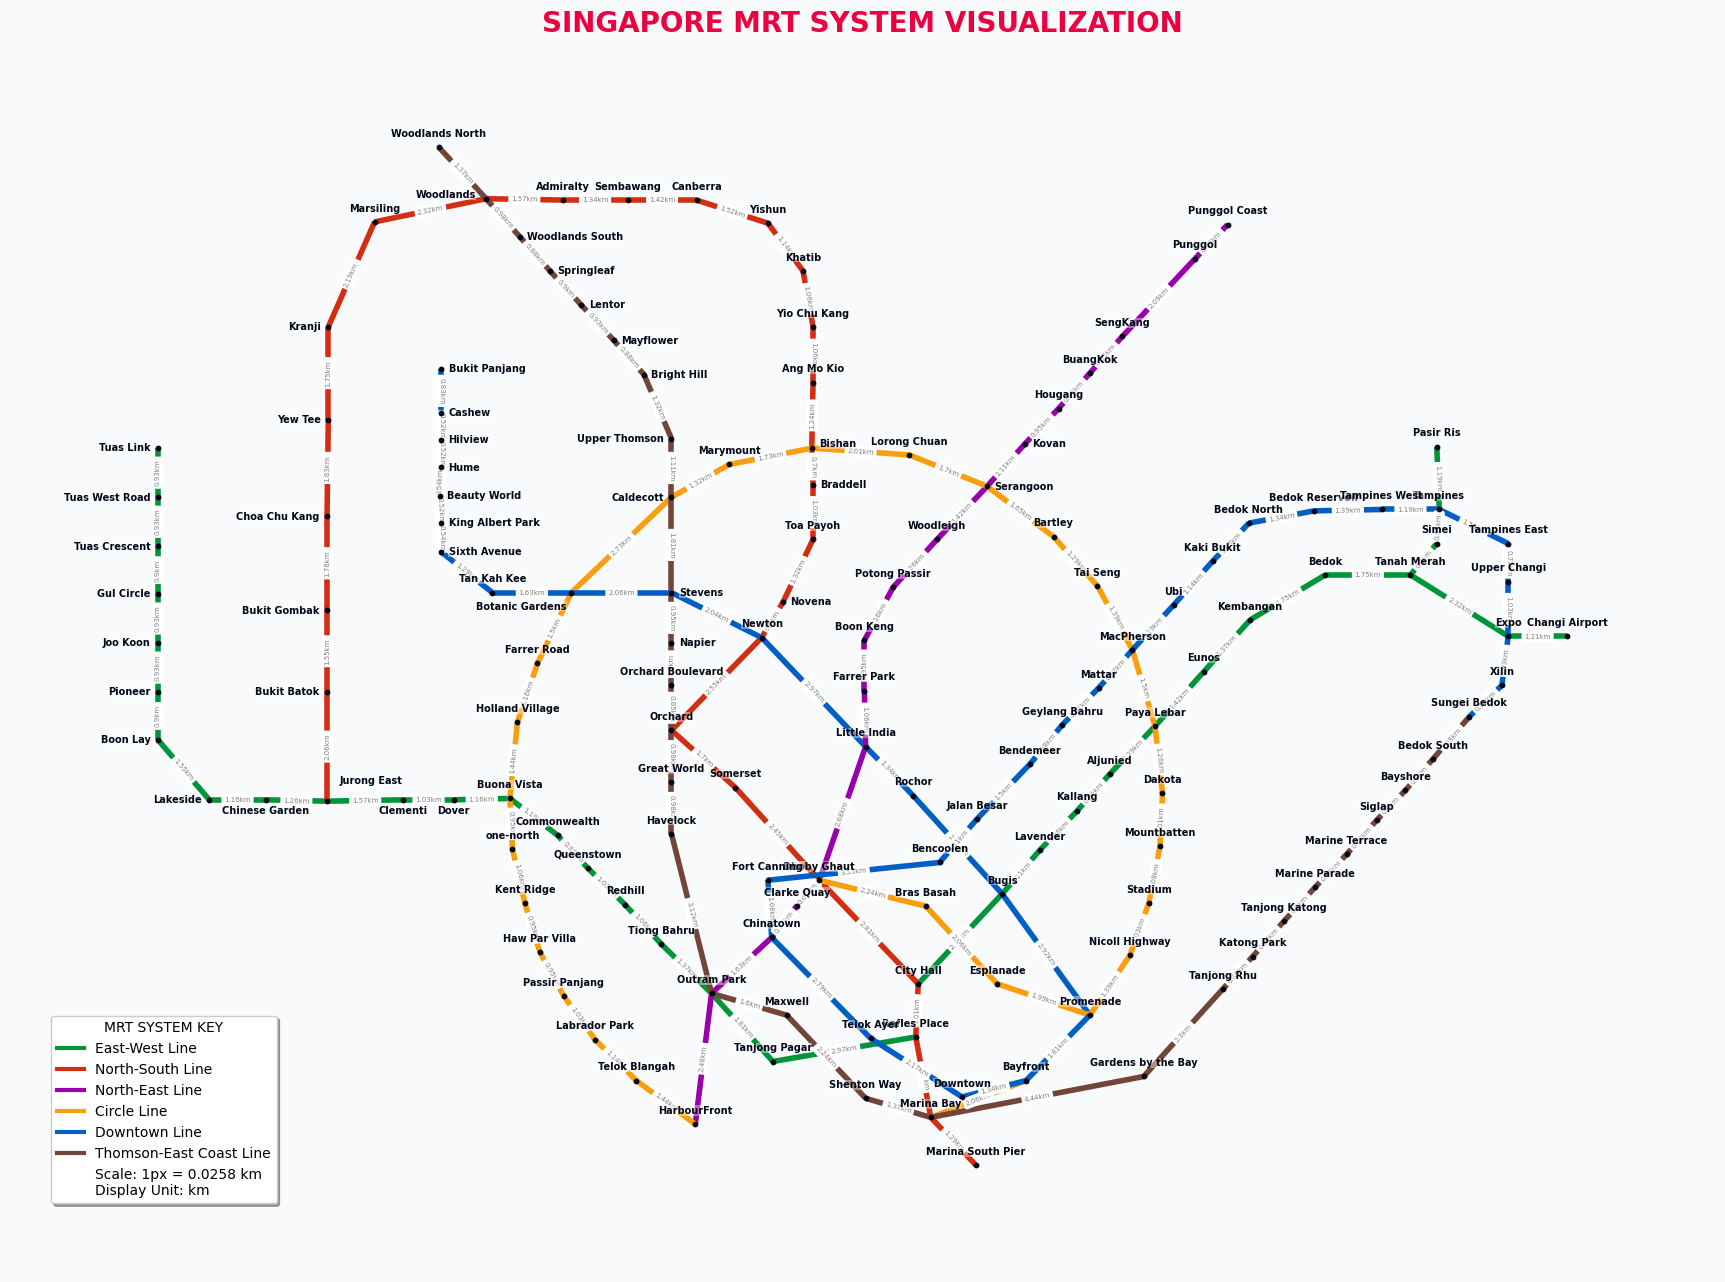

In [41]:
plt.figure(figsize=(22, 16), facecolor="#f8fafc")

edge_colors = [G[u][v]['color'] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=4, alpha=1)
nx.draw_networkx_nodes(G, pos, node_size=10, node_color="#020618")

for name, (x, y) in pos.items():
    current_pos = (x, y + 10)
    ha_choice = 'center'
    f_size = 7 

    if name in ["Napier", "Stevens", "Novena", "Braddell", "Serangoon", "Kovan",
            "Bukit Panjang", "Cashew", "Hilview", "Hume", "Beauty World", "King Albert Park", 
            "Sixth Avenue","Woodlands South", "Springleaf", "Lentor", 
            "Mayflower", "Bright Hill"]:
        current_pos = (x + 6, y)
        ha_choice = 'left'
    
    elif name in ["Dover", "Clementi", "Chinese Garden"]:
        current_pos = (x, y - 8)
        ha_choice = 'center'

    elif name in ["Jurong East"]:
        current_pos = (x + 35, y + 15)
        ha_choice = 'center'
    
    elif name in ["Botanic Gardens"]:
        current_pos = (x - 40 , y - 10)
        ha_choice = 'center'

    elif name in ["Lakeside", "Boon Lay", "Pioneer", "Joo Koon", "Gul Circle", 
            "Tuas Crescent", "Tuas West Road", "Tuas Link","Bukit Batok", "Bukit Gombak", "Choa Chu Kang", "Yew Tee", 
            "Kranji", "Upper Thomson", "Caldecott"]:
        current_pos = (x - 6, y)
        ha_choice = 'right'

    elif name in ["Woodlands"]:
        current_pos = (x - 8, y + 3)
        ha_choice = 'right'

    elif name in ["Bishan"]:
        current_pos = (x + 6, y + 3)
        ha_choice = 'left'


    nx.draw_networkx_labels(
        G, 
        pos={name: current_pos}, 
        labels={name: name},     
        font_size=f_size, 
        font_weight='bold', 
        font_color="#020615", 
        horizontalalignment=ha_choice,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.4, pad=0.05) 
    )

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=5, rotate=True, alpha=0.5)

seen_labels = set()
for line_name, info in mrt_data.items():
    clean_name = line_name.replace(" Main", "").replace(" Extension", "")
    clean_name = clean_name.split(' 1')[0].split(' 2')[0]
    
    if clean_name not in seen_labels:
        plt.plot([], color=info["color"], label=clean_name, linewidth=3)
        seen_labels.add(clean_name)
        
scale_text = f"Scale: 1px = {conv_km} km\nDisplay Unit: {unit_label}"
plt.plot([], ' ', label=scale_text)
plt.legend(
    title="MRT SYSTEM KEY", 
    loc='lower left', 
    bbox_to_anchor=(0.02, 0.05), 
    shadow=True,
    fontsize='medium'
)
plt.title("SINGAPORE MRT SYSTEM VISUALIZATION", color="#ec003f", fontsize=20, fontweight='bold')
plt.axis('off')
plt.show()

Task 2:
- Total network length: Add up all the distances of the edges (in both kilometers and miles).
- Average distance: Divide the total length by the number of edges (in both kilometers and miles).

In [42]:
all_km = [G[u][v]['km'] for u, v in G.edges()]
all_mi = [G[u][v]['miles'] for u, v in G.edges()]

In [43]:
num_edges = len(all_km)

total_km = sum(all_km)
total_mi = sum(all_mi)

avg_km = total_km / num_edges
avg_mi = total_mi / num_edges

In [45]:
print("MRT NETWORK STATISTICS - ALL STATIONS")
print("-" * 40)
print(f"Total network length: {total_km:.3f} km ({total_mi:.2f} miles)")
print(f"Average distance between stations: {avg_km:.2f} km ({avg_mi:.2f} miles)")

MRT NETWORK STATISTICS - ALL STATIONS
----------------------------------------
Total network length: 233.920 km (145.43 miles)
Average distance between stations: 1.40 km (0.87 miles)
